# Task 1
Підготуйте корпус текстів.
* Зберіть невеликий набір (10-15 речень) з відгуками або твітами про продукт.
* Приведіть усі тексти до нижнього регістру, видаліть пунктуацію.
* Розділіть тексти на токени і збережіть результат у список списків (кожен підсписок — одне речення).
* Перевірте кількість речень і середню довжину в словах.

In [1]:
fname = "feedbacks.txt"
import re
from nltk.corpus import stopwords

def prepare(phrase:str)->str:
   return re.sub('\n', ' ', re.sub(r'([^\w\s])+','', phrase.lower()))

with open(fname, "r") as f:
    feedbacks = [prepare(fb) for fb in f.readlines()]

stop_words = stopwords.words('english')

print(feedbacks[:3])

['the product quality exceeded my expectations and feels very durable ', 'easy to use right out of the box with clear instructions ', 'the design is modern and attractive ']


In [2]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download(["punkt_tab", "stopwords", "wordnet"])

tokens = [[w for w in word_tokenize(fb) if not w in stop_words] for fb in feedbacks]


tokens[:3]

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Golo_bs09\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Golo_bs09\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Golo_bs09\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


[['product', 'quality', 'exceeded', 'expectations', 'feels', 'durable'],
 ['easy', 'use', 'right', 'box', 'clear', 'instructions'],
 ['design', 'modern', 'attractive']]

In [3]:
length_words = 0
count_words = 0

In [4]:
for i in tokens:
    count_words += 1
    length_words += len(i)


print(f'Sentences count: {len(tokens)}')
print(f'Average word length: {length_words / count_words}')

Sentences count: 30
Average word length: 5.3


# Task 2
Побудуйте модель Word2Vec.
* Використовуйте бібліотеку gensim.models.Word2Vec.
* Параметри: vector_size = 100, window = 5, min_count = 1, sg = 1.
* Навчіть модель на підготовленому корпусі.
* Виведіть вектор слова good (якщо воно є в корпусі).



In [5]:
from gensim.models import Word2Vec
model = Word2Vec(vector_size = 100, window = 5, min_count = 1, sg = 1,
                sentences=tokens
                )

In [6]:
word = 'good'
try:
    vector = model.wv[word]
    print(vector)
except:
    print(f"Word: '{word}' not found")

[ 3.8127881e-03  1.5542797e-03 -3.1328457e-03 -7.2656600e-03
  2.3884834e-03  5.2687428e-03 -6.6421363e-03  5.0603412e-03
  3.4959542e-03  3.6515570e-03 -5.0975578e-03 -3.8842789e-03
 -4.4417757e-04  7.1240580e-03  7.0692585e-03 -3.1717038e-03
 -4.4249594e-03 -3.3076385e-03 -8.0361972e-03 -6.5494645e-03
 -4.2287875e-03 -9.0948204e-03 -9.0188887e-03  2.9760578e-03
  5.0936346e-03 -5.6970108e-04  8.0860133e-04 -5.3957966e-03
  3.1056348e-03 -2.5551557e-03 -1.5090294e-03 -1.1265464e-03
  3.7127337e-03 -4.8417458e-03 -6.6469256e-03 -4.9617393e-03
  3.2130633e-03 -8.3826436e-03  9.5338952e-03 -6.1691478e-03
 -3.1513257e-03 -9.8139141e-03 -2.6424606e-03 -2.5957127e-03
 -2.1057713e-03 -6.6682054e-03  3.8947128e-03  5.0915118e-05
  9.7705757e-05  8.8510923e-03 -5.5800411e-03 -4.4732908e-04
 -7.5468333e-03 -1.9311592e-03  7.3709120e-03  8.1760893e-03
 -5.7534124e-03  1.2825453e-03  5.3912746e-03  1.1164012e-03
  8.2717324e-03 -4.8035509e-03 -6.9723460e-03  7.3291119e-03
  4.9979473e-03  9.92630

# Task 3
Дослідіть семантичну близькість слів.
* Використовуйте метод most_similar() для пошуку слів, близьких за змістом до good, bad і quality.
* Відобразіть результати в таблиці:
| Target word | Close words | Cosine similarity |
|---|---|---|
| good | great, nice, amazing | 0.91, 0.87, 0.85 |
| bad | poor, terrible, awful | 0.88, 0.83, 0.81 |

In [7]:
words = ["good", "bad", "quality"]
model.wv.most_similar(words[0], topn=3)

[('products', 0.26652899384498596),
 ('still', 0.2553039789199829),
 ('addressed', 0.2529166340827942)]

In [18]:
from IPython.display import Markdown as md

# valid_words = [w for w in words if w in model.wv]
# list_word = []
# list_num = []

# tg = (list_word, list_num)


# for i in valid_words:
#     list_word.append(model.wv.most_similar(i[0], topn=3))
#     list_word.append(model.wv.most_similar(i[1], topn=3))
  
# md("\n".join((
#     "| Target word | Close words | Cosine similarity |",
#     "|-|-|-|",
#     *(f"{w} | {1} | {model.wv.most_similar(w, topn=3)[0][1]:.2f}" for w in valid_words)
# )))

([], [])


KeyError: "Key 'g' not present in vocabulary"

# Task 4
Візуалізуйте зв'язки між словами.
* Виберіть 20 найчастіших слів корпусу.
* Отримайте їхні векторні подання з моделі Word2Vec.
* Зменшіть розмірність до 2D за допомогою sklearn.decomposition.PCA.
* Побудуйте scatter-графік, де кожна точка — слово.
* Підпишіть точки та збережіть графік у файл word2vec_visualization.png.
* Порівняйте результати Word2Vec з переднавченими векторами GloVe (доступні через gensim.downloader.load('glove-wiki-gigaword-100')).
* Визначте, які пари слів найбільш схожі за змістом в обох моделях

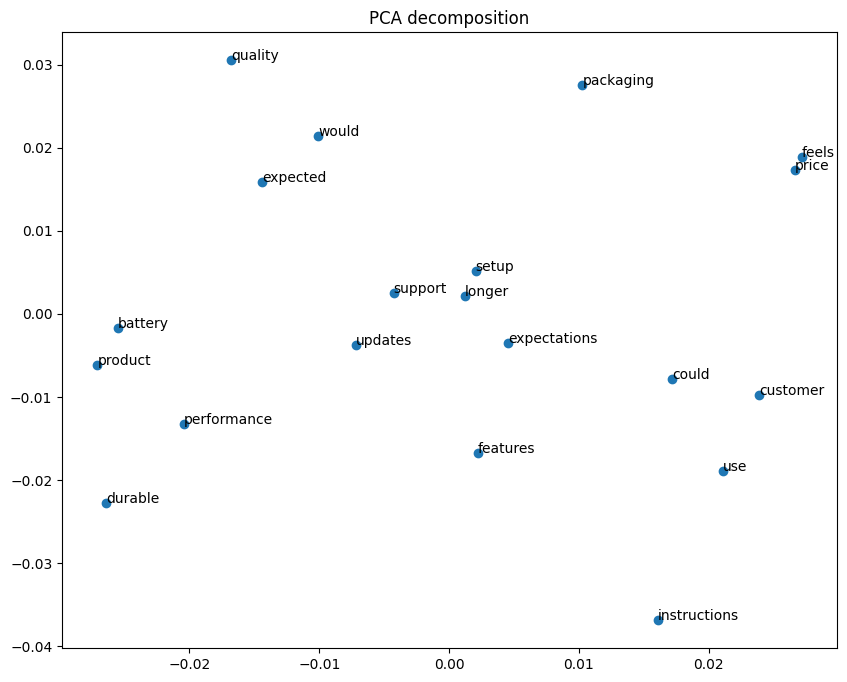

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words_20 = model.wv.index_to_key[:20]
wv_20 = model.wv[words_20]

pca = PCA(n_components=2)
result = pca.fit_transform(wv_20)

plt.figure(figsize=(10,8))
plt.scatter(result[:,0], result[:,1])
plt.title('PCA decomposition')

for i, w in enumerate(list(words_20)):
    plt.annotate(w, xy=(result[i,0], result[i,1]))

plt.savefig('pc.png')
plt.show()

In [10]:
import gensim.downloader as gdl
glove = gdl.load('glove-wiki-gigaword-100')

In [11]:
print(glove.most_similar('good', topn=5))

[('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762274742126), ('kind', 0.8288268446922302), ('very', 0.8260800242424011)]


In [16]:
len(model.wv.index_to_key)

126